# DATA 266 — Homework 6: Self-Supervised and Contrastive Representation Learning (STL-10)

**Personal parameters (Step 0, Section 0.1):** SID4 = 1605, SEED = 1605.
Per the assignment, the "second model with a different hyperparameter configuration" from Step 0 is
skipped here, because this homework already trains three different models.

| Part | What is trained | Labels used |
|---|---|---|
| A | ResNet-18 end-to-end, supervised | 500 labeled train images (10%) |
| B | ResNet-18 on rotation prediction (0/90/180/270°) → frozen → linear classifier | pretext: all 100,000 unlabeled; probe: same 500 |
| C | ResNet-18 + MLP projection head, SimCLR (NT-Xent, cosine, τ = 0.2) → frozen → linear classifier | pretext: 20,000 unlabeled; probe: same 500 |
| D | Top-5 cosine nearest neighbours of test-set embeddings for all three encoders | — |

The backbone is the same in every part: `torchvision.models.resnet18(weights=None)` (random init, no
pretrained weights) with its `fc` layer removed, giving a 512-d embedding. Images are used at STL-10's
native 96×96 resolution. Code shared with DataLoader worker processes lives in `hw6_lib.py`.

In [1]:
import json, os, random, tarfile, time, hashlib
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
import hw6_lib as L

SEED = 1605
SMOKE = os.environ.get("HW6_SMOKE") == "1"   # tiny end-to-end check of the pipeline; the real run has SMOKE=False
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR = "data"
BIN_DIR = os.path.join(DATA_DIR, "stl10_binary")
OUT = "outputs_smoke" if SMOKE else "outputs"
os.makedirs(OUT, exist_ok=True)
log = L.Logger(os.path.join(OUT, "train_progress.log"))

# The three encoders are expensive to train (~3 h total on this laptop). Each training cell saves its
# weights + per-epoch history; on later executions the cell reloads them instead of retraining, unless
# HW6_RETRAIN=1. Everything downstream (linear probes, test accuracy, Part D) is always recomputed.
RETRAIN = os.environ.get("HW6_RETRAIN") == "1"
def cached(ckpt, hist):
    return not RETRAIN and os.path.exists(ckpt) and os.path.exists(hist)

CFG = dict(
    labeled_fraction=0.10,
    sup_epochs=15, sup_batch=32, sup_lr=1e-3, sup_wd=5e-4,
    rot_epochs=15, rot_batch=128, rot_lr=1e-3, rot_wd=5e-4, rot_warmup_steps=500,
    simclr_subset=20000, simclr_epochs=20, simclr_batch=128, simclr_lr=1e-3, simclr_wd=1e-6, tau=0.2,
    probe_epochs=20, probe_batch=25, probe_lr=3e-3, probe_wd=1e-4,
    knn_k=5,
)
if SMOKE:
    CFG.update(sup_epochs=1, rot_epochs=1, simclr_subset=512, simclr_epochs=1, probe_epochs=1)
print("torch", torch.__version__, "| device", device, "| SMOKE", SMOKE)
print(json.dumps(CFG, indent=1))

torch 2.11.0 | device mps | SMOKE False
{
 "labeled_fraction": 0.1,
 "sup_epochs": 15,
 "sup_batch": 32,
 "sup_lr": 0.001,
 "sup_wd": 0.0005,
 "rot_epochs": 15,
 "rot_batch": 128,
 "rot_lr": 0.001,
 "rot_wd": 0.0005,
 "rot_warmup_steps": 500,
 "simclr_subset": 20000,
 "simclr_epochs": 20,
 "simclr_batch": 128,
 "simclr_lr": 0.001,
 "simclr_wd": 1e-06,
 "tau": 0.2,
 "probe_epochs": 20,
 "probe_batch": 25,
 "probe_lr": 0.003,
 "probe_wd": 0.0001,
 "knn_k": 5
}


## Data: STL-10

The official binary release (`stl10_binary.tar.gz`) is extracted once, then read as memory-mapped arrays so the 100,000-image unlabeled split (2.8 GB) is never fully loaded into RAM.

train (5000, 3, 96, 96) test (8000, 3, 96, 96) unlabeled (100000, 3, 96, 96)
train class counts [500 500 500 500 500 500 500 500 500 500] | test class counts [800 800 800 800 800 800 800 800 800 800]
labeled subset: 500 images, per class: [50 50 50 50 50 50 50 50 50 50]
SimCLR subset: 20000 unlabeled images -> data/simclr_subset_20000_seed1605.npy


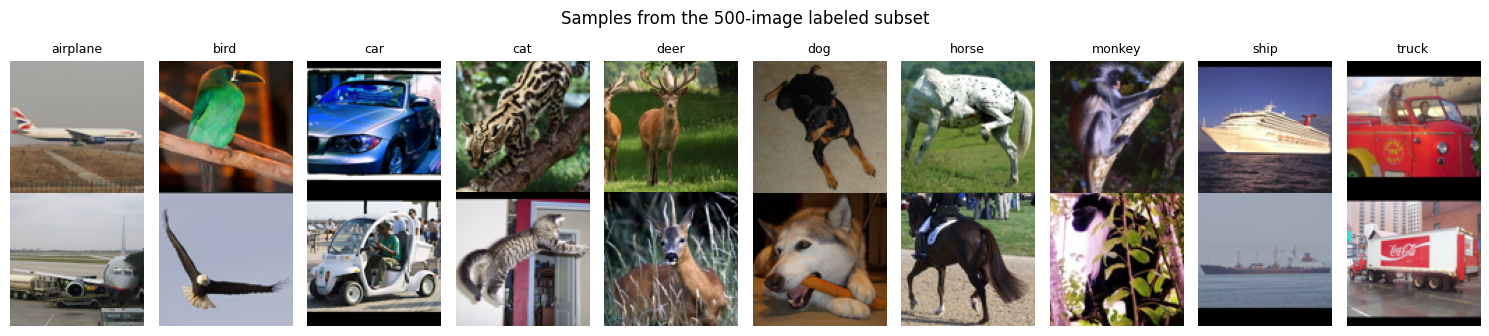

In [2]:
if not os.path.exists(os.path.join(BIN_DIR, "unlabeled_X.bin")):
    with tarfile.open(os.path.join(DATA_DIR, "stl10_binary.tar.gz")) as tf:
        tf.extractall(DATA_DIR, filter="data")

train_X, train_y = L.stl10_images(BIN_DIR, "train"), L.stl10_labels(BIN_DIR, "train")
test_X,  test_y  = L.stl10_images(BIN_DIR, "test"),  L.stl10_labels(BIN_DIR, "test")
unlab_X = L.stl10_images(BIN_DIR, "unlabeled")
if SMOKE:
    unlab_X = unlab_X[:2000]
    keep = np.random.default_rng(SEED).permutation(len(test_X))[:1000]; keep.sort()
    test_X, test_y = np.ascontiguousarray(test_X[keep]), test_y[keep]
else:
    test_X = np.ascontiguousarray(test_X)  # 8,000 images, 221 MB: small enough to hold in RAM
print("train", train_X.shape, "test", test_X.shape, "unlabeled", unlab_X.shape)
print("train class counts", np.bincount(train_y), "| test class counts", np.bincount(test_y))

# 10% of the labeled train split, stratified: 50 images per class = 500. Reused in Parts A, B and C.
rng = np.random.default_rng(SEED)
n_per_class = int(round(CFG["labeled_fraction"] * len(train_y) / 10))
sub_idx = np.sort(np.concatenate([rng.choice(np.where(train_y == c)[0], n_per_class, replace=False) for c in range(10)]))
sub_X, sub_y = np.ascontiguousarray(train_X[sub_idx]), train_y[sub_idx]
print("labeled subset:", len(sub_idx), "images, per class:", np.bincount(sub_y))
np.save(os.path.join(OUT, "labeled_subset_indices.npy"), sub_idx)

# SimCLR subset: 20,000 random unlabeled images, written to a .npy that worker processes memory-map.
simclr_idx = np.sort(rng.choice(len(unlab_X), min(CFG["simclr_subset"], len(unlab_X)), replace=False))
SIMCLR_NPY = os.path.join(DATA_DIR, f"simclr_subset_{len(simclr_idx)}_seed{SEED}.npy")
if not os.path.exists(SIMCLR_NPY):
    np.save(SIMCLR_NPY, np.ascontiguousarray(unlab_X[simclr_idx]))
print("SimCLR subset:", len(simclr_idx), "unlabeled images ->", SIMCLR_NPY)

fig, axes = plt.subplots(2, 10, figsize=(15, 3.4))
for c in range(10):
    for r in range(2):
        axes[r, c].imshow(sub_X[np.where(sub_y == c)[0][r]].transpose(1, 2, 0)); axes[r, c].axis("off")
    axes[0, c].set_title(L.STL10_CLASSES[c], fontsize=9)
plt.suptitle("Samples from the 500-image labeled subset"); plt.tight_layout()
plt.savefig(os.path.join(OUT, "labeled_subset_samples.png"), dpi=110); plt.show()

## Shared helpers: linear probe on a frozen encoder

Used identically for Parts B and C. The encoder is put in `eval()` mode (so BatchNorm running statistics
do not change either), all its parameters get `requires_grad=False`, its forward pass runs under
`torch.no_grad()`, and only a `nn.Linear(512, 10)` is given to the optimizer. To *verify* rather than
assume that the encoder stayed frozen, a hash of its full `state_dict` (weights + BN buffers) is compared
before and after probe training. Training images get the same light augmentation as Part A
(random horizontal flip + translation).

**Feature standardization.** Before the linear layer, each of the 512 features is standardized with a
*fixed* mean/std computed once from the (un-augmented) 500 training images — never from test data. This
is a constant affine map, so the probe is still exactly one linear classifier (it could be folded into
the `Linear` weights). It matters because encoders trained on different objectives produce features on
very different scales: in a first run without it, the rotation encoder's features had a median
per-dimension std of 0.0095 (vs. 0.73 overall for the supervised encoder), and the same Adam probe
could not even fit the 500 *training* images (25% train accuracy, loss 2.06 after 20 epochs). The fixed
recipe below (standardize, batch 25 → 400 steps, Adam lr 3e-3, cosine) was chosen by checking that the
probe converges on training data only; the test set was not used to pick it.

In [3]:
def state_hash(module):
    h = hashlib.sha256()
    for k, v in module.state_dict().items():
        h.update(k.encode()); h.update(v.detach().cpu().contiguous().numpy().tobytes())
    return h.hexdigest()

def linear_probe(encoder, name):
    encoder.to(device).eval()
    for p in encoder.parameters():
        p.requires_grad_(False)
    before = state_hash(encoder)
    torch.manual_seed(SEED)
    train_feats = L.embed(encoder, sub_X, device)  # un-augmented, train images only
    clf = nn.Sequential(L.Standardize(train_feats.mean(0), train_feats.std(0)), nn.Linear(512, 10)).to(device)
    opt = torch.optim.Adam(clf[1].parameters(), lr=CFG["probe_lr"], weight_decay=CFG["probe_wd"])
    steps_per_epoch = len(sub_X) // CFG["probe_batch"]
    total, step, hist = CFG["probe_epochs"] * steps_per_epoch, 0, []
    for ep in range(CFG["probe_epochs"]):
        clf.train(); perm = np.random.default_rng(SEED + ep).permutation(len(sub_X)); losses, correct = [], 0
        for b in range(steps_per_epoch):
            idx = perm[b * CFG["probe_batch"]:(b + 1) * CFG["probe_batch"]]
            x = L.gpu_flip_translate(L.to_input(sub_X[idx], device)); y = torch.as_tensor(sub_y[idx], device=device)
            with torch.no_grad():
                feats = encoder(x)
            logits = clf(feats)
            loss = F.cross_entropy(logits, y)
            for g in opt.param_groups: g["lr"] = L.cosine_lr(step, total, CFG["probe_lr"])
            opt.zero_grad(); loss.backward(); opt.step(); step += 1
            losses.append(loss.item()); correct += (logits.argmax(1) == y).sum().item()
        hist.append(dict(epoch=ep + 1, loss=float(np.mean(losses)), train_acc=correct / (steps_per_epoch * CFG["probe_batch"])))
        log(f"[{name} probe] epoch {ep+1}/{CFG['probe_epochs']} loss {hist[-1]['loss']:.4f} train_acc {hist[-1]['train_acc']:.3f}")
    after = state_hash(encoder)
    assert before == after, "encoder changed during linear evaluation!"
    model = L.EncoderWithHead(encoder, clf).eval()
    test_acc = L.accuracy(model, test_X, test_y, device)
    log(f"[{name} probe] encoder state_dict hash unchanged ({after[:12]}...) -> frozen. TEST ACC = {test_acc:.4f}")
    return clf, hist, test_acc

RESULTS = {}

## Part A — Supervised with limited labels (500 images)

ResNet-18 trained end-to-end from random init on the 500-image subset for 15 epochs: Adam (lr 1e-3,
weight decay 5e-4, cosine decay), batch 32, random horizontal flip + translation, cross-entropy.

In [4]:
torch.manual_seed(SEED)
sup_encoder = L.make_encoder()
sup_model = L.EncoderWithHead(sup_encoder, nn.Linear(512, 10)).to(device)
CKPT_A, HIST_A = os.path.join(OUT, "partA_supervised_resnet18.pt"), os.path.join(OUT, "partA_history.json")
if cached(CKPT_A, HIST_A):
    sup_model.load_state_dict(torch.load(CKPT_A, map_location=device))
    _h = json.load(open(HIST_A)); hist_A, time_A = _h["history"], _h["minutes"] * 60
    print(f"Loaded trained Part A weights from {CKPT_A} (trained {time_A/60:.1f} min; per-epoch log below).")
    for h in hist_A: print(f"  epoch {h['epoch']:2d}  loss {h['loss']:.4f}  train_acc {h['train_acc']:.3f}")
else:
    opt = torch.optim.Adam(sup_model.parameters(), lr=CFG["sup_lr"], weight_decay=CFG["sup_wd"])
    steps_per_epoch = int(np.ceil(len(sub_X) / CFG["sup_batch"])); total = CFG["sup_epochs"] * steps_per_epoch
    hist_A, step, t0 = [], 0, time.time()
    for ep in range(CFG["sup_epochs"]):
        sup_model.train(); perm = np.random.default_rng(SEED + ep).permutation(len(sub_X)); losses, correct = [], 0
        for b in range(steps_per_epoch):
            idx = perm[b * CFG["sup_batch"]:(b + 1) * CFG["sup_batch"]]
            x = L.gpu_flip_translate(L.to_input(sub_X[idx], device)); y = torch.as_tensor(sub_y[idx], device=device)
            logits = sup_model(x); loss = F.cross_entropy(logits, y)
            for g in opt.param_groups: g["lr"] = L.cosine_lr(step, total, CFG["sup_lr"])
            opt.zero_grad(); loss.backward(); opt.step(); step += 1
            losses.append(loss.item()); correct += (logits.argmax(1) == y).sum().item()
        hist_A.append(dict(epoch=ep + 1, loss=float(np.mean(losses)), train_acc=correct / len(sub_X)))
        log(f"[A supervised] epoch {ep+1}/{CFG['sup_epochs']} loss {hist_A[-1]['loss']:.4f} train_acc {hist_A[-1]['train_acc']:.3f}")
    time_A = time.time() - t0
    torch.save(sup_model.state_dict(), CKPT_A)
    json.dump(dict(history=hist_A, minutes=time_A / 60), open(HIST_A, "w"), indent=1)
acc_A = L.accuracy(sup_model, test_X, test_y, device)
log(f"[A supervised] trained in {time_A/60:.1f} min. TEST ACC = {acc_A:.4f}")
RESULTS["A_supervised"] = dict(test_acc=acc_A, train_minutes=time_A / 60, history=hist_A)
print(f"\nPart A test accuracy (8,000 test images): {acc_A*100:.2f}%")

Loaded trained Part A weights from outputs/partA_supervised_resnet18.pt (trained 0.5 min; per-epoch log below).
  epoch  1  loss 2.2635  train_acc 0.164
  epoch  2  loss 1.8559  train_acc 0.300
  epoch  3  loss 1.6488  train_acc 0.376
  epoch  4  loss 1.6256  train_acc 0.406
  epoch  5  loss 1.5344  train_acc 0.424
  epoch  6  loss 1.3811  train_acc 0.480
  epoch  7  loss 1.3012  train_acc 0.518
  epoch  8  loss 1.2734  train_acc 0.504
  epoch  9  loss 1.1776  train_acc 0.564
  epoch 10  loss 1.0983  train_acc 0.596
  epoch 11  loss 0.9319  train_acc 0.668
  epoch 12  loss 0.8077  train_acc 0.716
  epoch 13  loss 0.7569  train_acc 0.758
  epoch 14  loss 0.6840  train_acc 0.766
  epoch 15  loss 0.6374  train_acc 0.780


[23:44:50] [A supervised] trained in 0.5 min. TEST ACC = 0.4784



Part A test accuracy (8,000 test images): 47.84%


## Part B — Rotation self-supervised learning

**Pretext task.** Every step samples a batch of 128 unlabeled images, applies flip + translation, and
rotates each image by 0°, 90°, 180° or 270° (exactly balanced within the batch); the encoder plus a
`Linear(512, 4)` rotation head is trained with cross-entropy to predict which. One epoch is one pass
over **all 100,000 unlabeled images** (each with one random rotation), for 15 epochs: Adam (lr 1e-3,
weight decay 5e-4, 500-step warmup then cosine decay).

Then the rotation head is discarded, the encoder is frozen, and a linear classifier is trained on the
same 500 labeled images (20 epochs).

In [5]:
torch.manual_seed(SEED)
rot_encoder = L.make_encoder()
rot_model = L.EncoderWithHead(rot_encoder, nn.Linear(512, 4)).to(device)
CKPT_B, HIST_B = os.path.join(OUT, "partB_rotation_pretext_resnet18.pt"), os.path.join(OUT, "partB_pretext_history.json")
if cached(CKPT_B, HIST_B):
    rot_model.load_state_dict(torch.load(CKPT_B, map_location=device))
    _h = json.load(open(HIST_B)); hist_B, time_B = _h["history"], _h["minutes"] * 60
    print(f"Loaded trained rotation encoder + head from {CKPT_B} (per-epoch log below).")
    for h in hist_B: print(f"  epoch {h['epoch']:2d}  loss {h['loss']:.4f}  rotation_acc {h['rot_acc']:.3f}")
else:
    opt = torch.optim.Adam(rot_model.parameters(), lr=CFG["rot_lr"], weight_decay=CFG["rot_wd"])
    N_un = len(unlab_X); steps_per_epoch = N_un // CFG["rot_batch"]; total = CFG["rot_epochs"] * steps_per_epoch
    hist_B, step, t0 = [], 0, time.time()
    for ep in range(CFG["rot_epochs"]):
        rot_model.train(); perm = np.random.default_rng(SEED + 100 + ep).permutation(N_un); losses, correct = [], 0
        for b in range(steps_per_epoch):
            idx = np.sort(perm[b * CFG["rot_batch"]:(b + 1) * CFG["rot_batch"]])  # sorted -> sequential memmap reads
            x, y = L.rotate_batch(L.gpu_flip_translate(L.to_input(unlab_X[idx], device)))
            logits = rot_model(x); loss = F.cross_entropy(logits, y)
            for g in opt.param_groups: g["lr"] = L.cosine_lr(step, total, CFG["rot_lr"], CFG["rot_warmup_steps"])
            opt.zero_grad(); loss.backward(); opt.step(); step += 1
            losses.append(loss.item()); correct += (logits.argmax(1) == y).sum().item()
            if b % 200 == 0:
                log(f"[B rotation] epoch {ep+1} step {b}/{steps_per_epoch} loss {loss.item():.4f} ({(time.time()-t0)/60:.1f} min)")
        hist_B.append(dict(epoch=ep + 1, loss=float(np.mean(losses)), rot_acc=correct / (steps_per_epoch * CFG["rot_batch"])))
        log(f"[B rotation] EPOCH {ep+1}/{CFG['rot_epochs']} loss {hist_B[-1]['loss']:.4f} rotation_acc {hist_B[-1]['rot_acc']:.3f}")
    time_B = time.time() - t0
    torch.save(rot_model.state_dict(), CKPT_B)
    json.dump(dict(history=hist_B, minutes=time_B / 60), open(HIST_B, "w"), indent=1)

# Did the pretext task generalize? Rotation accuracy on all 4 rotations of every test image (never trained on).
@torch.no_grad()
def rotation_test_acc():
    rot_model.eval(); correct = 0
    for i in range(0, len(test_X), 256):
        x = L.to_input(test_X[i:i + 256], device)
        for k in range(4):
            correct += (rot_model(torch.rot90(x, k, dims=(2, 3))).argmax(1) == k).sum().item()
    return correct / (4 * len(test_X))
rot_pretext_test_acc = rotation_test_acc()
log(f"[B rotation] pretext training wall-clock {time_B/60:.1f} min; rotation accuracy on test images = {rot_pretext_test_acc:.4f}")

Loaded trained rotation encoder + head from outputs/partB_rotation_pretext_resnet18.pt (per-epoch log below).
  epoch  1  loss 1.0355  rotation_acc 0.553
  epoch  2  loss 0.8497  rotation_acc 0.655
  epoch  3  loss 0.7791  rotation_acc 0.687
  epoch  4  loss 0.7265  rotation_acc 0.709
  epoch  5  loss 0.6787  rotation_acc 0.732
  epoch  6  loss 0.6374  rotation_acc 0.748
  epoch  7  loss 0.5968  rotation_acc 0.767
  epoch  8  loss 0.5581  rotation_acc 0.784
  epoch  9  loss 0.5193  rotation_acc 0.799
  epoch 10  loss 0.4851  rotation_acc 0.814
  epoch 11  loss 0.4525  rotation_acc 0.828
  epoch 12  loss 0.4206  rotation_acc 0.840
  epoch 13  loss 0.3934  rotation_acc 0.850
  epoch 14  loss 0.3790  rotation_acc 0.857
  epoch 15  loss 0.3708  rotation_acc 0.860


[23:45:21] [B rotation] pretext training wall-clock 280.0 min; rotation accuracy on test images = 0.8985


In [6]:
# Remove the rotation head: keep only the encoder, frozen, and train a linear classifier on the 500 labels.
rot_clf, hist_B_probe, acc_B = linear_probe(rot_encoder, "B rotation")
torch.save(rot_clf.state_dict(), os.path.join(OUT, "partB_linear_probe.pt"))
RESULTS["B_rotation"] = dict(test_acc=acc_B, pretext_rotation_test_acc=rot_pretext_test_acc,
                             pretext_minutes=time_B / 60, pretext_history=hist_B, probe_history=hist_B_probe)
print(f"\nPart B test accuracy (frozen rotation encoder + linear): {acc_B*100:.2f}%")

[23:45:22] [B rotation probe] epoch 1/20 loss 2.2698 train_acc 0.200


[23:45:23] [B rotation probe] epoch 2/20 loss 2.1371 train_acc 0.220


[23:45:24] [B rotation probe] epoch 3/20 loss 2.0396 train_acc 0.250


[23:45:24] [B rotation probe] epoch 4/20 loss 1.9425 train_acc 0.314


[23:45:25] [B rotation probe] epoch 5/20 loss 1.9228 train_acc 0.280


...

[23:45:32] [B rotation probe] epoch 18/20 loss 1.6751 train_acc 0.408


[23:45:32] [B rotation probe] epoch 19/20 loss 1.6591 train_acc 0.450


[23:45:33] [B rotation probe] epoch 20/20 loss 1.6714 train_acc 0.390


[23:45:39] [B rotation probe] encoder state_dict hash unchanged (117915bfb9f1...) -> frozen. TEST ACC = 0.3599



Part B test accuracy (frozen rotation encoder + linear): 35.99%


## Part C — Contrastive learning (SimCLR-style)

* **Data:** a fixed random subset of 20,000 unlabeled images.
* **Two views per image**, each produced independently by the four augmentations from the demo:
  `RandomResizedCrop(96, scale=(0.2, 1.0))`, `RandomHorizontalFlip()`,
  `ColorJitter(0.4, 0.4, 0.4, 0.1)` applied with p = 0.8, and `RandomGrayscale(p=0.2)`.
* **Model:** ResNet-18 encoder → 512-d `h` → MLP projection head `Linear(512,512)–ReLU–Linear(512,128)` → `z`.
* **Loss:** NT-Xent on cosine similarity with temperature τ = 0.2: for a batch of 128 images (256 views),
  each view's positive is its partner view and the other 254 views are negatives.
* **Training:** 20 epochs, Adam (lr 1e-3, weight decay 1e-6, 1-epoch warmup then cosine decay).
  Augmentation runs in 4 CPU worker processes that memory-map the subset file.

Then the projection head is discarded, the encoder is frozen, and the same linear probe as Part B is trained.

In [7]:
torch.manual_seed(SEED)
simclr_encoder = L.make_encoder().to(device)
proj = L.projection_head().to(device)
CKPT_C, HIST_C = os.path.join(OUT, "partC_simclr_resnet18.pt"), os.path.join(OUT, "partC_pretext_history.json")
if cached(CKPT_C, HIST_C):
    _ck = torch.load(CKPT_C, map_location=device)
    simclr_encoder.load_state_dict(_ck["encoder"]); proj.load_state_dict(_ck["projection_head"])
    _h = json.load(open(HIST_C)); hist_C, time_C = _h["history"], _h["minutes"] * 60
    print(f"Loaded trained SimCLR encoder + projection head from {CKPT_C} (per-epoch log below).")
    for h in hist_C: print(f"  epoch {h['epoch']:2d}  NT-Xent loss {h['loss']:.4f}  positive-pair top-1 {h['pair_top1']:.3f}")
else:
    params = list(simclr_encoder.parameters()) + list(proj.parameters())
    opt = torch.optim.Adam(params, lr=CFG["simclr_lr"], weight_decay=CFG["simclr_wd"])
    ds = L.SimCLRPairs(SIMCLR_NPY)
    loader = torch.utils.data.DataLoader(ds, batch_size=CFG["simclr_batch"], shuffle=True, drop_last=True,
                                         num_workers=0 if SMOKE else 4, persistent_workers=not SMOKE,
                                         generator=torch.Generator().manual_seed(SEED))
    steps_per_epoch = len(loader); total = CFG["simclr_epochs"] * steps_per_epoch
    hist_C, step, t0 = [], 0, time.time()
    mean, std = L.MEAN.to(device), L.STD.to(device)
    for ep in range(CFG["simclr_epochs"]):
        simclr_encoder.train(); proj.train(); losses, top1 = [], []
        for b, (v1, v2) in enumerate(loader):
            v1 = (v1.to(device).float() / 255 - mean) / std
            v2 = (v2.to(device).float() / 255 - mean) / std
            z1, z2 = proj(simclr_encoder(v1)), proj(simclr_encoder(v2))
            loss = L.nt_xent(z1, z2, CFG["tau"])
            for g in opt.param_groups: g["lr"] = L.cosine_lr(step, total, CFG["simclr_lr"], steps_per_epoch)
            opt.zero_grad(); loss.backward(); opt.step(); step += 1
            losses.append(loss.item())
            with torch.no_grad():  # how often the partner view is the most similar of the 2N-1 candidates
                zn = F.normalize(torch.cat([z1, z2]), dim=1); s = zn @ zn.t(); s.fill_diagonal_(-2); n = len(z1)
                top1.append((s.argmax(1).cpu() == torch.cat([torch.arange(n, 2 * n), torch.arange(n)])).float().mean().item())
            if b % 50 == 0:
                log(f"[C SimCLR] epoch {ep+1} step {b}/{steps_per_epoch} loss {loss.item():.4f} ({(time.time()-t0)/60:.1f} min)")
        hist_C.append(dict(epoch=ep + 1, loss=float(np.mean(losses)), pair_top1=float(np.mean(top1))))
        log(f"[C SimCLR] EPOCH {ep+1}/{CFG['simclr_epochs']} loss {hist_C[-1]['loss']:.4f} positive-pair top-1 {hist_C[-1]['pair_top1']:.3f}")
    time_C = time.time() - t0
    del loader
    torch.save({"encoder": simclr_encoder.state_dict(), "projection_head": proj.state_dict()}, CKPT_C)
    json.dump(dict(history=hist_C, minutes=time_C / 60), open(HIST_C, "w"), indent=1)
log(f"[C SimCLR] pretext training wall-clock {time_C/60:.1f} min")

Loaded trained SimCLR encoder + projection head from outputs/partC_simclr_resnet18.pt (per-epoch log below).
  epoch  1  NT-Xent loss 4.2184  positive-pair top-1 0.183
  epoch  2  NT-Xent loss 3.2851  positive-pair top-1 0.401
  epoch  3  NT-Xent loss 2.9656  positive-pair top-1 0.516
  epoch  4  NT-Xent loss 2.7857  positive-pair top-1 0.586
  epoch  5  NT-Xent loss 2.6643  positive-pair top-1 0.637
  epoch  6  NT-Xent loss 2.5778  positive-pair top-1 0.674
  epoch  7  NT-Xent loss 2.5134  positive-pair top-1 0.697
  epoch  8  NT-Xent loss 2.4530  positive-pair top-1 0.721
  epoch  9  NT-Xent loss 2.3957  positive-pair top-1 0.748
  epoch 10  NT-Xent loss 2.3607  positive-pair top-1 0.761
  epoch 11  NT-Xent loss 2.2954  positive-pair top-1 0.787
  epoch 12  NT-Xent loss 2.2595  positive-pair top-1 0.799
  epoch 13  NT-Xent loss 2.2110  positive-pair top-1 0.817
  epoch 14  NT-Xent loss 2.1739  positive-pair top-1 0.831
  epoch 15  NT-Xent loss 2.1524  positive-pair top-1 0.837
  epoc

In [8]:
# Remove the projection head: keep only the encoder, frozen, and train the same linear probe.
del proj
simclr_clf, hist_C_probe, acc_C = linear_probe(simclr_encoder, "C SimCLR")
torch.save(simclr_clf.state_dict(), os.path.join(OUT, "partC_linear_probe.pt"))
RESULTS["C_simclr"] = dict(test_acc=acc_C, pretext_minutes=time_C / 60, pretext_history=hist_C, probe_history=hist_C_probe)
print(f"\nPart C test accuracy (frozen SimCLR encoder + linear): {acc_C*100:.2f}%")

[23:45:41] [C SimCLR probe] epoch 1/20 loss 1.5448 train_acc 0.468


[23:45:41] [C SimCLR probe] epoch 2/20 loss 1.0981 train_acc 0.602


[23:45:42] [C SimCLR probe] epoch 3/20 loss 1.0018 train_acc 0.632


[23:45:42] [C SimCLR probe] epoch 4/20 loss 0.9200 train_acc 0.658


[23:45:43] [C SimCLR probe] epoch 5/20 loss 0.8826 train_acc 0.672


...

[23:45:51] [C SimCLR probe] epoch 18/20 loss 0.6172 train_acc 0.788


[23:45:51] [C SimCLR probe] epoch 19/20 loss 0.6123 train_acc 0.814


[23:45:52] [C SimCLR probe] epoch 20/20 loss 0.6326 train_acc 0.788


[23:45:59] [C SimCLR probe] encoder state_dict hash unchanged (c5d7a5fc1fc3...) -> frozen. TEST ACC = 0.5600



Part C test accuracy (frozen SimCLR encoder + linear): 56.00%


## Results so far: training curves and test accuracy

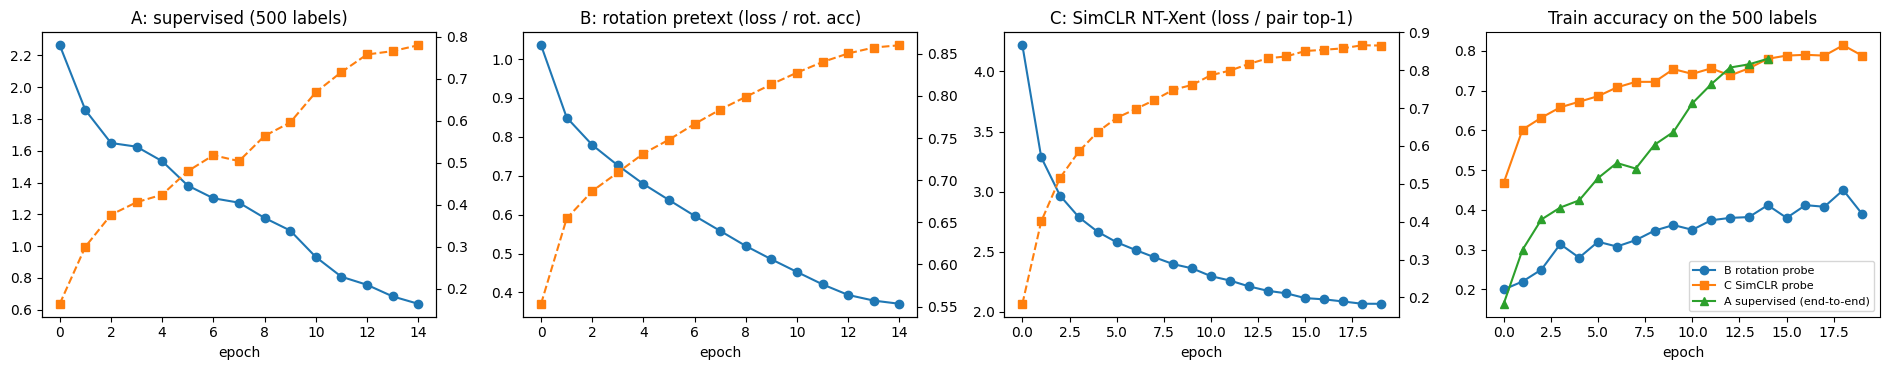

Model                                          Test accuracy
A  Supervised ResNet-18 (500 labels, end-to-end)         47.84%
B  Rotation SSL (frozen) + linear (500 labels)         35.99%
C  SimCLR (frozen) + linear (500 labels)              56.00%



Per-class test accuracy (%):
class       A supervised    B rotation      C SimCLR
airplane            73.1          49.1          67.0
bird                34.4          31.9          52.1
car                 71.5          51.7          68.6
cat                 37.4          40.9          44.6
deer                43.9          31.8          57.6
dog                 29.6           8.5          27.0
horse               55.9          40.6          61.5
monkey              34.4          29.4          42.4
ship                52.2          44.9          71.9
truck               46.0          31.1          67.2


In [9]:
fig, ax = plt.subplots(1, 4, figsize=(19, 3.8))
ax[0].plot([h["loss"] for h in hist_A], "o-", label="train loss"); ax0b = ax[0].twinx()
ax0b.plot([h["train_acc"] for h in hist_A], "s--", color="tab:orange", label="train acc"); ax[0].set_title("A: supervised (500 labels)")
ax[1].plot([h["loss"] for h in hist_B], "o-"); ax1b = ax[1].twinx(); ax1b.plot([h["rot_acc"] for h in hist_B], "s--", color="tab:orange")
ax[1].set_title("B: rotation pretext (loss / rot. acc)")
ax[2].plot([h["loss"] for h in hist_C], "o-"); ax2b = ax[2].twinx(); ax2b.plot([h["pair_top1"] for h in hist_C], "s--", color="tab:orange")
ax[2].set_title("C: SimCLR NT-Xent (loss / pair top-1)")
ax[3].plot([h["train_acc"] for h in hist_B_probe], "o-", label="B rotation probe")
ax[3].plot([h["train_acc"] for h in hist_C_probe], "s-", label="C SimCLR probe")
ax[3].plot([h["train_acc"] for h in hist_A], "^-", label="A supervised (end-to-end)"); ax[3].legend(fontsize=8)
ax[3].set_title("Train accuracy on the 500 labels")
for a in ax: a.set_xlabel("epoch")
plt.tight_layout(); plt.savefig(os.path.join(OUT, "training_curves.png"), dpi=110); plt.show()

print(f"{'Model':45s} {'Test accuracy':>14s}")
for name, acc in [("A  Supervised ResNet-18 (500 labels, end-to-end)", acc_A),
                  ("B  Rotation SSL (frozen) + linear (500 labels)", acc_B),
                  ("C  SimCLR (frozen) + linear (500 labels)", acc_C)]:
    print(f"{name:45s} {acc*100:13.2f}%")

def per_class_acc(model):
    model.eval(); preds = []
    with torch.no_grad():
        for i in range(0, len(test_X), 256):
            preds.append(model(L.to_input(test_X[i:i + 256], device)).argmax(1).cpu().numpy())
    preds = np.concatenate(preds)
    return [float((preds[test_y == c] == c).mean()) for c in range(10)]
pc = {"A supervised": per_class_acc(sup_model),
      "B rotation": per_class_acc(L.EncoderWithHead(rot_encoder, rot_clf)),
      "C SimCLR": per_class_acc(L.EncoderWithHead(simclr_encoder, simclr_clf))}
print("\nPer-class test accuracy (%):")
print(f"{'class':10s}" + "".join(f"{k:>14s}" for k in pc))
for c in range(10):
    print(f"{L.STL10_CLASSES[c]:10s}" + "".join(f"{pc[k][c]*100:14.1f}" for k in pc))
RESULTS["per_class_test_acc"] = {k: dict(zip(L.STL10_CLASSES, v)) for k, v in pc.items()}

## Part D — Nearest-neighbour visualization

For each of the three encoders, every test image is mapped to its 512-d encoder output (the layer
just before the classifier / rotation head / projection head: global-average-pooled ResNet-18 features),
L2-normalized, so a dot product is cosine similarity. For each query, the top-5 most similar *other*
test images are retrieved. The same queries are used for all three encoders.

To complement the hand-picked examples with a number, the same retrieval is run for **all 8,000 test
images**: precision@5 (fraction of the 5 neighbours that share the query's class) and leave-one-out
5-NN majority-vote accuracy. These need no labels during training and no linear layer, so they measure
the embedding space itself.

In [10]:
encoders = {"Supervised": sup_encoder, "Rotation SSL": rot_encoder, "SimCLR": simclr_encoder}
EMB = {name: F.normalize(L.embed(enc, test_X, device), dim=1) for name, enc in encoders.items()}

def topk_neighbours(E, k):
    nbrs = []
    for i in range(0, len(E), 1000):
        s = E[i:i + 1000] @ E.t()
        s[torch.arange(s.shape[0]), torch.arange(i, i + s.shape[0])] = -2  # exclude the query itself
        nbrs.append(s.topk(k, dim=1))
    return torch.cat([v for v, _ in nbrs]), torch.cat([j for _, j in nbrs])

ty = torch.as_tensor(test_y); K = CFG["knn_k"]; NN = {}
knn_stats = {}
for name, E in EMB.items():
    sims, idx = topk_neighbours(E, K); NN[name] = (sims, idx)
    match = (ty[idx] == ty[:, None]).float()
    vote = torch.mode(ty[idx], dim=1).values
    knn_stats[name] = dict(precision_at_5=match.mean().item(), knn5_acc=(vote == ty).float().mean().item(),
                           mean_top5_cosine=sims.mean().item())
print(f"{'Encoder':14s} {'precision@5':>12s} {'5-NN acc':>10s} {'mean top-5 cos':>15s}")
for name, s in knn_stats.items():
    print(f"{name:14s} {s['precision_at_5']*100:11.2f}% {s['knn5_acc']*100:9.2f}% {s['mean_top5_cosine']:15.3f}")
RESULTS["D_nearest_neighbours"] = knn_stats

Encoder         precision@5   5-NN acc  mean top-5 cos
Supervised           40.93%     47.35%           0.967
Rotation SSL         24.31%     28.90%           0.996
SimCLR               49.71%     57.89%           0.917


query test indices: [6352, 6138, 2465, 7554] classes: ['cat', 'horse', 'deer', 'monkey']


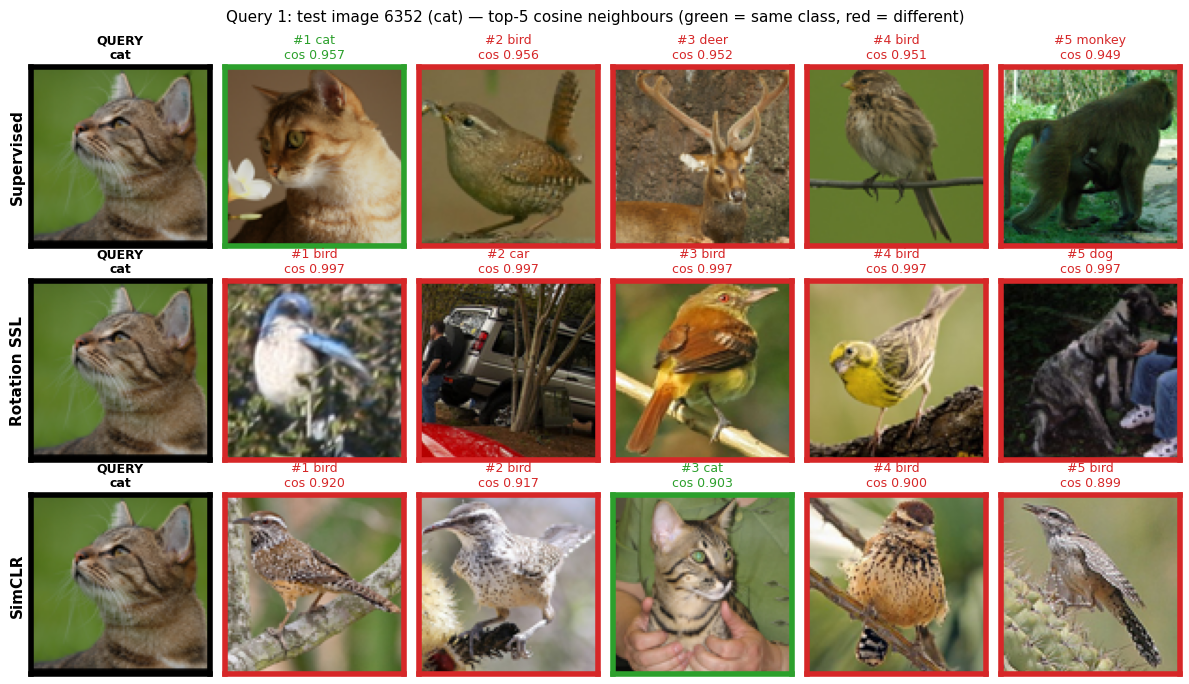

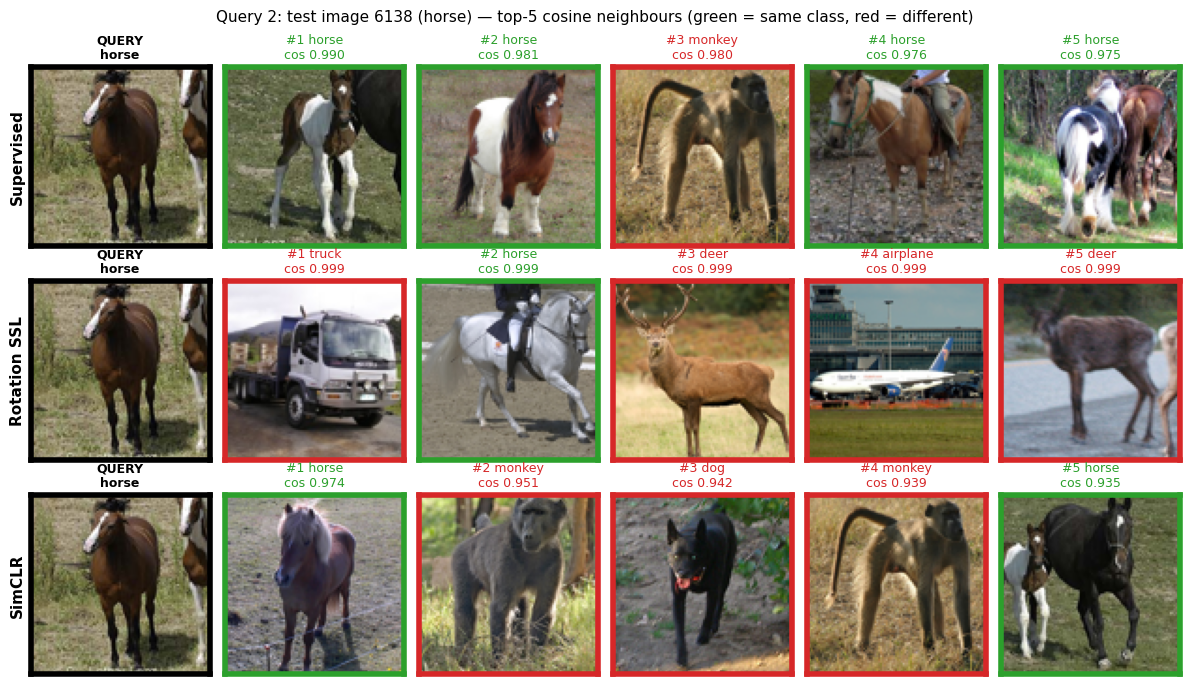

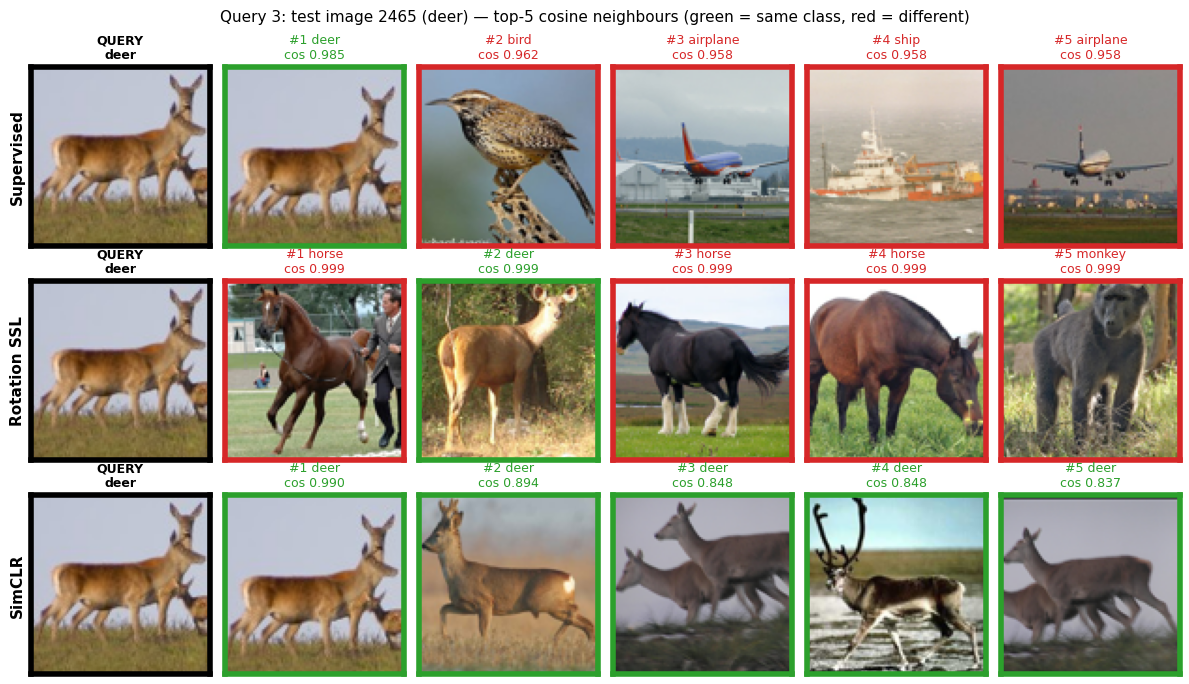

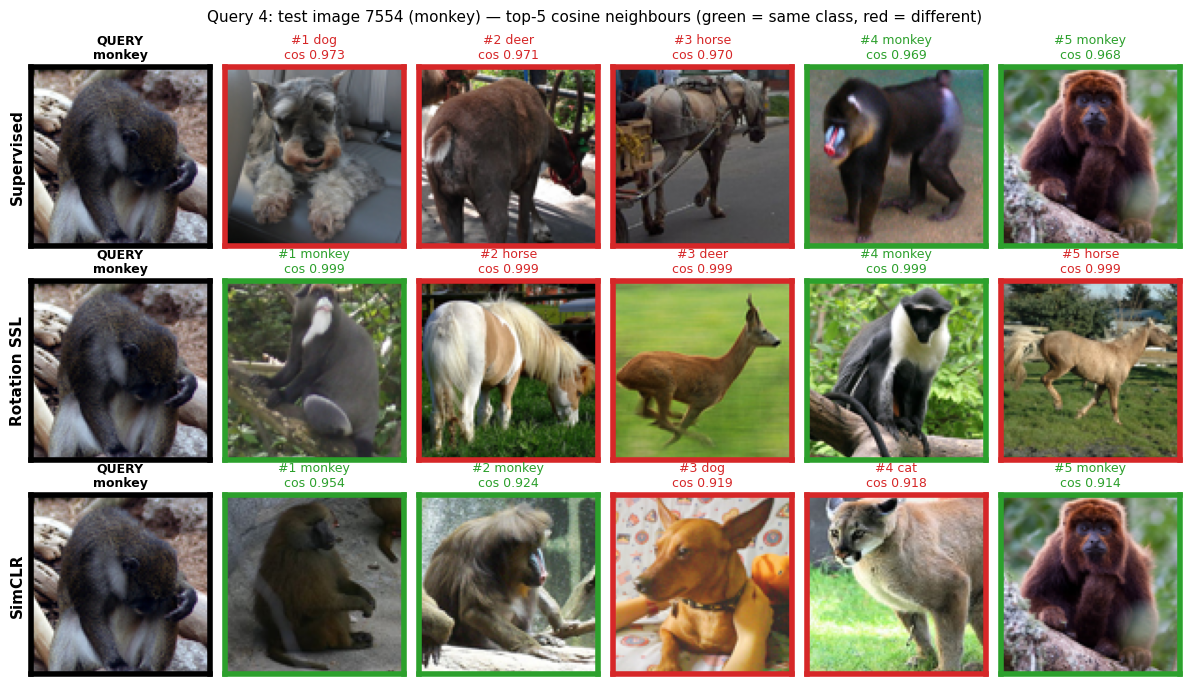

query                             Supervised    Rotation SSL          SimCLR   (neighbours of the same class, out of 5)
query1_6352_cat                            1               0               1
query2_6138_horse                          4               1               2
query3_2465_deer                           1               1               5
query4_7554_monkey                         2               2               3


In [11]:
# Query images: 4 test images from 4 different classes, chosen at random with the fixed seed
# (not hand-picked to favour any encoder). The same 4 queries are used for all three encoders.
qrng = np.random.default_rng(SEED)
query_classes = qrng.choice(10, 4, replace=False)
queries = [int(qrng.choice(np.where(test_y == c)[0])) for c in query_classes]
print("query test indices:", queries, "classes:", [L.STL10_CLASSES[test_y[q]] for q in queries])

def show_border(ax, color):
    for s in ax.spines.values(): s.set_edgecolor(color); s.set_linewidth(4)
    ax.set_xticks([]); ax.set_yticks([])

nn_table = {}
for qi, q in enumerate(queries):
    fig, axes = plt.subplots(3, K + 1, figsize=(2.0 * (K + 1), 7.0))
    for r, name in enumerate(encoders):
        sims, idx = NN[name]
        axes[r, 0].imshow(test_X[q].transpose(1, 2, 0)); show_border(axes[r, 0], "black")
        axes[r, 0].set_title(f"QUERY\n{L.STL10_CLASSES[test_y[q]]}", fontsize=9, fontweight="bold")
        axes[r, 0].set_ylabel(name, fontsize=11, fontweight="bold")
        row = []
        for j in range(K):
            n = int(idx[q, j]); ok = test_y[n] == test_y[q]
            axes[r, j + 1].imshow(test_X[n].transpose(1, 2, 0)); show_border(axes[r, j + 1], "tab:green" if ok else "tab:red")
            axes[r, j + 1].set_title(f"#{j+1} {L.STL10_CLASSES[test_y[n]]}\ncos {sims[q, j]:.3f}", fontsize=9,
                                     color="tab:green" if ok else "tab:red")
            row.append(dict(test_index=n, label=L.STL10_CLASSES[test_y[n]], cosine=float(sims[q, j])))
        nn_table.setdefault(f"query{qi+1}_{q}_{L.STL10_CLASSES[test_y[q]]}", {})[name] = row
    plt.suptitle(f"Query {qi+1}: test image {q} ({L.STL10_CLASSES[test_y[q]]}) — top-{K} cosine neighbours "
                 f"(green = same class, red = different)", fontsize=11)
    plt.tight_layout(); plt.savefig(os.path.join(OUT, f"partD_query{qi+1}_{L.STL10_CLASSES[test_y[q]]}.png"), dpi=110); plt.show()

print(f"{'query':28s}" + "".join(f"{n:>16s}" for n in encoders) + "   (neighbours of the same class, out of 5)")
for key, per_enc in nn_table.items():
    qlab = key.split("_")[-1]
    print(f"{key:28s}" + "".join(f"{sum(r['label'] == qlab for r in per_enc[n]):>16d}" for n in encoders))
RESULTS["D_queries"] = nn_table

In [12]:
RESULTS["config"] = CFG; RESULTS["seed"] = SEED; RESULTS["device"] = str(device); RESULTS["smoke"] = SMOKE
RESULTS["torch_version"] = torch.__version__
with open(os.path.join(OUT, "all_outputs.json"), "w") as f:
    json.dump(RESULTS, f, indent=1)
print("saved", os.path.join(OUT, "all_outputs.json"))

saved outputs/all_outputs.json


## Comparison and discussion

### Results (8,000-image STL-10 test set; every model saw the same 500 labeled images)

| Model | Linear / end-to-end **test accuracy** | Train acc. on the 500 labels (final epoch) | 5-NN acc. (embedding only) | Precision@5 | Mean top-5 cosine |
|---|---|---|---|---|---|
| A — Supervised ResNet-18, end-to-end | 47.84% | 78.0% | 47.35% | 40.93% | 0.967 |
| B — Rotation SSL, frozen + linear | 35.99% | 39.0% | 28.90% | 24.31% | **0.996** |
| C — SimCLR, frozen + linear | **56.00%** | 78.8% | **57.89%** | **49.71%** | 0.917 |

Chance is 10%. Pretext diagnostics: the rotation network predicts the rotation of **unseen test images**
correctly 89.9% of the time. SimCLR picks the partner view out of 255 candidates 86.5% of the time in the
last epoch.

Per-class test accuracy shows the same ranking almost everywhere. SimCLR is best on 7 of 10 classes
(bird, cat, deer, horse, monkey, ship, truck). The supervised model wins on airplane (73.1%) and car (71.5%), the two
classes most identifiable by colour, background and shape, and narrowly on dog (29.6% vs. 27.0%).
**Dog** is the hardest class for all three (29.6% / 8.5% / 27.0%).

### Which model performed best, and why — SimCLR

SimCLR wins on every measure: +8.2 points over supervised and +20 points over rotation in linear
accuracy, and it is also the best when **no classifier at all** is trained (5-NN 57.9%). Three reasons:

1. **It learns from far more images than the supervised model, with a task that needs semantics.** To pick out
   the other view of the same image among 254 negatives, after a random 20–100% crop, a flip, strong
   colour jitter and possible grayscaling, the encoder has to encode *what is in the image*. Colour,
   exact position and scale are not enough. These are exactly the invariances a classifier needs. The
   20,000 unlabeled images give 40× more data than the 500 labels.
2. **The invariances it learns are built in, not memorised.** Colour jitter and grayscale stop it from
   relying on hue. This shows in Part D: it matched the deer query to five other deer under different
   lighting.
3. **The projection head absorbs the augmentation-specific information.** The contrastive loss
   is applied to `z = g(h)`, so the 512-d `h` we probe keeps information that the loss would
   otherwise throw away.

### Why the other models performed the way they did

**Supervised (A, 47.8%) — limited by labels, and it overfits.** 11 million parameters trained from
scratch on 500 images reach 78% train accuracy but 47.8% test accuracy, a 30-point generalisation
gap. Train accuracy is still rising at epoch 15, so the model hasn't converged, but more epochs would
mostly widen the gap. With so few labels the network latches onto whatever separates *these* 500 images:
colour and background. Part D shows this directly. The tabby cat on a green background retrieves birds,
a deer and a monkey on green/olive backgrounds. The deer against a pale grey sky retrieves two airplanes
and a ship against grey skies. That is also why it is strongest on airplane, car and ship. Its labels do
help where the classes are visually consistent: for the horse query, 4 of 5 neighbours are horses.

**Rotation (B, 36.0%) — the network solved its pretext task, but the last layer is specialised to it.**
89.9% held-out rotation accuracy shows that learning happened. Predicting "which way is up" mainly needs
orientation cues: the horizon and sky position, where legs and the ground are, upright vs. sideways body
outlines, and text. Those cues are shared by *all* classes, so the final layer, which sits right under
the rotation head, keeps them and discards what distinguishes a dog from a horse. Several measurements
confirm this:
- The probe can't even fit the training labels (39% train accuracy, vs. 79% for SimCLR with the identical probe).
- The features are low-dimensional and sparse: median per-dimension std 0.0095, and 41% of activations are exactly 0.
- All embeddings lie in a very narrow cone (mean top-5 cosine 0.996, every neighbour ≈ 0.999), so cosine distances barely separate classes.

The Part D rows show it clearly. The standing horse retrieves a truck, an airplane, a deer and another
horse, all side-on objects standing on the ground with a horizon behind them. The deer query retrieves
three horses and a monkey, all four-legged animals in the same pose. These neighbours look alike *in
layout*, not in class. It is the worst on dog (8.5%) because dogs are photographed in every pose, and
that varied geometry is exactly what the rotation features encode.

### What changes could improve each model

**A — Supervised**
- Stronger regularisation and augmentation: RandomResizedCrop, colour jitter, mixup/cutmix, label smoothing, dropout.
- A smaller or narrower network, or a small-image ResNet stem (3×3 conv1, no max-pool).
- More epochs with early stopping on a held-out split.
- Best of all: initialise from the SimCLR encoder and fine-tune end-to-end (semi-supervised).

**B — Rotation**
- Probe an earlier layer (`layer3`, or pooled `layer3` + `layer4`). In RotNet (Gidaris et al., 2018), features from the middle layers are much better than the last ones for exactly the reason above.
- Train on all four rotations of each image per step instead of one random rotation.
- Train longer: the pretext accuracy was still rising.
- Crop out the STL-10 letterbox bars, which are a shortcut cue for orientation.
- Combine rotation with a contrastive or other objective.

**C — SimCLR**
- More negatives per step and longer training. SimCLR benefits strongly from batch sizes of 256–4096 and hundreds of epochs; this run used 128 images for 20 epochs, and the loss is still falling.
- Use all 100k unlabeled images instead of 20k.
- Add the Gaussian-blur augmentation from the original paper.
- Use a small-image ResNet stem so 96×96 images keep more spatial resolution.
- Use a larger projection head, or LARS/SGD with a higher learning rate.
- Fine-tune instead of linear-probing once the representation is good.

**Probe (all)** — The linear probe sees only 500 labels. A probe with stronger augmentation, or kNN on top
of the linear probe, would help a little, but the representation is the real bottleneck.

### What the nearest-neighbour visualisations revealed about representation quality

- **SimCLR embeddings are organised by object identity.** The deer query returns 5/5 deer, and the
  monkey query returns 3/5 monkeys with mistakes that are other furry animals (dog, cougar-like cat).
  The tabby cat query returns textured, streaked birds and one tabby cat: it matched *fur and feather
  texture*, which shows that texture still carries a lot of weight in a 20-epoch SimCLR model. Across all
  8,000 queries it has the highest precision@5 (49.7%) and the widest spread of cosine values (top-5
  mean 0.917). Its embedding space uses its full range and puts different images at meaningfully
  different distances.
- **Supervised embeddings are organised by background and colour.** Neighbours share the background
  (green grass, grey sky) more often than the class, which is the overfitting signature of training on
  500 labels.
- **Rotation embeddings are organised by layout and orientation, and are nearly collapsed.** Every
  neighbour scores ≈ 0.999 cosine. Retrieval works only through tiny differences in a few active
  dimensions, and those encode pose and horizon rather than category.
- **The visual ranking matches the numbers.** kNN accuracy on raw embeddings (SimCLR 57.9 > supervised
  47.4 > rotation 28.9) gives the same order as the linear probe, so the result does not depend on the
  choice of classifier.

One caveat on the examples: STL-10's test set contains some near-duplicate images. The deer query's top
neighbour under both the supervised model and SimCLR (cosine 0.985 / 0.990) is visibly the same
photograph, re-cropped. The precision@5 and 5-NN numbers above average over all 8,000 queries, so one such
pair barely moves them.